In [1]:
import pandas, matplotlib_venn, matplotlib

In [2]:
dataDir = '/Users/adrian/research/bmcbf/067_urmia/results/degs/'

low_file = dataDir + 'effect_treatment_low_vs_disease.responders.tsv'
high_file = dataDir + 'effect_treatment_high_vs_disease.responders.tsv'

In [3]:
low = pandas.read_csv(low_file, sep='\t')
low = set(list(low.index))
print(len(low))

high = pandas.read_csv(high_file, sep='\t')
high = set(list(high.index))
print(len(high))

771
928


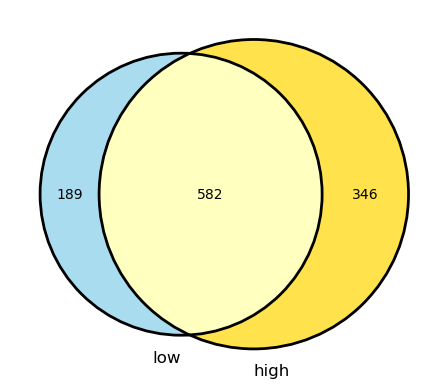

In [4]:
results = matplotlib_venn.venn2(subsets = [low, high], set_labels=['low', 'high'], set_colors=['skyblue', 'gold'], alpha=0.7)
matplotlib_venn.venn2_circles(subsets=[low, high])  

matplotlib.pyplot.show()


In [6]:
low_only  = low - high
high_only = high - low
shared    = low & high

In [8]:
import mygene

# one batched lookup (per-gene queries would be very slow)
mg = mygene.MyGeneInfo()
ids = sorted(low | high)
res = mg.querymany([i.split('.')[0] for i in ids],
                   scopes='ensembl.gene', fields='symbol',
                   species='human')                      # <-- set your species
id2sym = {}
for r in res:
    if 'symbol' in r:
        id2sym.setdefault(r['query'], r['symbol'])

for name, genes in [('low_only', low_only), ('high_only', high_only), ('shared', shared)]:
    n_mapped = 0
    with open(f'{name}.txt', 'w') as f:
        for g in sorted(genes):
            symbol = id2sym.get(g.split('.')[0])
            if symbol:
                f.write(f'{g}\t{symbol}\n')
                n_mapped += 1
            else:
                print(f'[{name}] no symbol found for {g}, wrote ID only')
                f.write(f'{g}\n')
    print(f'{name}: {len(genes)} written, {n_mapped} with symbol')

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found no hit:	['ENSG00000177133', 'ENSG00000235609', 'ENSG00000239332', 'ENSG00000260517', 'ENSG00000272482', 'ENS


[low_only] no symbol found for ENSG00000223969, wrote ID only
[low_only] no symbol found for ENSG00000260121, wrote ID only
[low_only] no symbol found for ENSG00000260578, wrote ID only
[low_only] no symbol found for ENSG00000271344, wrote ID only
[low_only] no symbol found for ENSG00000272540, wrote ID only
[low_only] no symbol found for ENSG00000282988, wrote ID only
low_only: 189 written, 183 with symbol
[high_only] no symbol found for ENSG00000093100, wrote ID only
[high_only] no symbol found for ENSG00000243696, wrote ID only
[high_only] no symbol found for ENSG00000249679, wrote ID only
[high_only] no symbol found for ENSG00000250899, wrote ID only
[high_only] no symbol found for ENSG00000257379, wrote ID only
[high_only] no symbol found for ENSG00000257524, wrote ID only
[high_only] no symbol found for ENSG00000259132, wrote ID only
[high_only] no symbol found for ENSG00000259171, wrote ID only
[high_only] no symbol found for ENSG00000260772, wrote ID only
[high_only] no symbol 